# Practice 1: Guillem Moreno Garcia
##  Objectives:
1. Learn to load data and analyse the properties.

2. Do a simple exploratory data analysis
3. Learn the **data cleaning and visualitzation** features of Pandas.
## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)
1.   Cars data: http://archive.ics.uci.edu/ml/datasets/Automobile.
- Predict **price** in dollars.

2. Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)


___________________________________

## First we load the Libraries
* Pandas: For dealing with tabulated data: excel + sql
* sklearn: Machine learning framework
* os: anciliary functions for dealing with the operating system

In [29]:
import pandas as pd
import sklearn
import os 

### Use the os library for generating the path to the file

In [30]:
File = "Bdcars.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\Users\guill\Downloads\FirstPractice\FirstPractice\Data\Bdcars.csv


### First rows of the file
**make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price**

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500

alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500

### Load the data by means of Pandas
- Note that the structure is a csv: Comma separated values
- The library recognizes the first line as the name of the columns
- Note the similarity with an *excel file*

#  See Appendix for  the meaning of the variables.

In [31]:
Data = pd.read_csv(Filename)
Data.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [32]:
print(f'Size of the database: {Data.shape} (rows X columns)')

Size of the database: (205, 24) (rows X columns)


## Deal with the Excel table as a Matrix => Transpose

In [33]:
Data.T.head(24)

,0,1,2,3,4,5,6,7,8,9,...,195,196,197,198,199,200,201,202,203,204
make,alfa-romero,alfa-romero,alfa-romero,audi,audi,audi,audi,audi,audi,audi,...,volvo,volvo,volvo,volvo,volvo,volvo,volvo,volvo,volvo,volvo
fuel-type,gas,gas,gas,gas,gas,gas,gas,gas,gas,gas,...,gas,gas,gas,gas,gas,gas,gas,gas,diesel,gas
aspiration,std,std,std,std,std,std,std,std,turbo,turbo,...,std,std,std,turbo,turbo,std,turbo,std,turbo,turbo
num-of-doors,two,two,two,four,four,two,four,four,four,two,...,four,four,four,four,four,four,four,four,four,four
body-style,convertible,convertible,hatchback,sedan,sedan,sedan,sedan,wagon,sedan,hatchback,...,wagon,sedan,wagon,sedan,wagon,sedan,sedan,sedan,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd,fwd,fwd,fwd,fwd,4wd,...,rwd,rwd,rwd,rwd,rwd,rwd,rwd,rwd,rwd,rwd
engine-location,front,front,front,front,front,front,front,front,front,front,...,front,front,front,front,front,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4,99.8,105.8,105.8,105.8,99.5,...,104.3,104.3,104.3,104.3,104.3,109.1,109.1,109.1,109.1,109.1
length,168.8,168.8,171.2,176.6,176.6,177.3,192.7,192.7,192.7,178.2,...,188.8,188.8,188.8,188.8,188.8,188.8,188.8,188.8,188.8,188.8
width,64.1,64.1,65.5,66.2,66.4,66.3,71.4,71.4,71.4,67.9,...,67.2,67.2,67.2,67.2,67.2,68.9,68.8,68.9,68.9,68.9


## First approximation to the Exploratory Data Analysis
###  Summary of the descriptive statitistics
Note that only affects the numerical values

In [34]:
Data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
wheel-base,205.0,98.76,6.02,86.6,94.5,97.0,102.4,120.9
length,205.0,174.05,12.34,141.1,166.3,173.2,183.1,208.1
width,205.0,65.91,2.15,60.3,64.1,65.5,66.9,72.3
height,205.0,53.72,2.44,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.57,520.68,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.91,41.64,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.14,3.97,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.22,6.54,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.75,6.89,16.0,25.0,30.0,34.0,54.0


## IMPORTANT: seems there is a problem with price
Price is not **float**  but is **object!**

In [35]:
Data[' price']

0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
200    16845
201    19045
202    21485
203    22470
204    22625
Name:  price, Length: 205, dtype: object

### Change the type of the column 'price'. From objet to float
Strategy: create a vector of Boolean values and use them for indexing the Dataframe

In [36]:
Data[' price'] != '?'

0      True
1      True
2      True
3      True
4      True
       ... 
200    True
201    True
202    True
203    True
204    True
Name:  price, Length: 205, dtype: bool

In [37]:
(Data[' price'] == '?').sum()

np.int64(4)

In [38]:
Data[Data[' price'] == '?'].T

,9,44,45,129
make,audi,isuzu,isuzu,porsche
fuel-type,gas,gas,gas,gas
aspiration,turbo,std,std,std
num-of-doors,two,two,four,two
body-style,hatchback,sedan,sedan,hatchback
drive-wheels,4wd,fwd,fwd,rwd
engine-location,front,front,front,front
wheel-base,99.5,94.5,94.5,98.4
length,178.2,155.9,155.9,175.7
width,67.9,63.6,63.6,72.3


In [39]:
Data =Data[Data[' price'] != '?']
print('Shape of the data: ',Data.shape)

Shape of the data:  (201, 24)


In [40]:
Data[' price'].astype('float').ravel().shape
 

C:\Users\guill\AppData\Local\Temp\ipykernel_39832\3369079381.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Data[' price'].astype('float').ravel().shape


(201,)

In [41]:
Data[' price'] = Data[' price'].astype('float').ravel()

C:\Users\guill\AppData\Local\Temp\ipykernel_39832\1161864231.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Data[' price'] = Data[' price'].astype('float').ravel()


In [42]:
Data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
wheel-base,201.0,98.80,6.07,86.6,94.5,97.0,102.4,120.9
length,201.0,174.20,12.32,141.1,166.8,173.2,183.5,208.1
width,201.0,65.89,2.10,60.3,64.1,65.5,66.6,72.0
height,201.0,53.77,2.45,47.8,52.0,54.1,55.5,59.8
curb-weight,201.0,2555.67,517.30,1488.0,2169.0,2414.0,2926.0,4066.0
engine-size,201.0,126.88,41.55,61.0,98.0,120.0,141.0,326.0
compression-ratio,201.0,10.16,4.00,7.0,8.6,9.0,9.4,23.0
city-mpg,201.0,25.18,6.42,13.0,19.0,24.0,30.0,49.0
highway-mpg,201.0,30.69,6.82,16.0,25.0,30.0,34.0,54.0
price,201.0,13207.13,7947.07,5118.0,7775.0,10295.0,16500.0,45400.0


 ### Exercise: <font color='red'>Correct all the numerical fields </font>

In [43]:
# 1. Define the possible numeric columns for both databases
possible_cols = [
    ' symboling', ' normalized-losses', ' wheel-base', ' length', ' width', 
    ' height', ' curb-weight', ' engine-size', ' bore', ' stroke', 
    ' compression-ratio', ' horsepower', ' peak-rpm', ' city-mpg', 
    ' highway-mpg', ' price', 'fixed acidity', 'volatile acidity', 
    'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality'
]

# 2. Filter out '?' and convert to float (using your syntax)
# This only runs on columns that actually exist in your current DataFrame
numeric_cols = [] 
for col in possible_cols:
    if col in Data.columns:
        Data = Data[Data[col] != '?']
        Data[col] = Data[col].astype('float').ravel()
        numeric_cols.append(col) # Add only the successes to our numeric list

# 3. Correlation will now work perfectly because we excluded 'alfa-romero'
print(f"Data corrected. New shape: {Data.shape}")
target = ' price' if ' price' in Data.columns else 'quality'
print(f"\nCorrelations with {target}:")
print(Data[numeric_cols].corr()[target].sort_values(ascending=False))

Data corrected. New shape: (195, 24)

Correlations with  price:
price                1.000000
engine-size          0.888942
curb-weight          0.835729
horsepower           0.811027
width                0.754273
length               0.695331
wheel-base           0.585793
bore                 0.546873
height               0.138291
stroke               0.093746
compression-ratio    0.069500
peak-rpm            -0.104333
city-mpg            -0.702685
highway-mpg         -0.715590
Name:  price, dtype: float64


C:\Users\guill\AppData\Local\Temp\ipykernel_39832\3621885353.py:17: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Data[col] = Data[col].astype('float').ravel()
C:\Users\guill\AppData\Local\Temp\ipykernel_39832\3621885353.py:17: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Data[col] = Data[col].astype('float').ravel()
C:\Users\guill\AppData\Local\Temp\ipykernel_39832\3621885353.py:17: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Data[col] = Data[col].astype('float').ravel()
C:\Users\guill\AppData\Local\Temp\ipykernel_39832\3621885353.py:17: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel i

## Lets see if there is a functional relationship between the variables and price
* Meaning of the Variables: see Apendix

In [44]:
Data.columns

Index([' make', ' fuel-type', ' aspiration', ' num-of-doors', ' body-style',
       ' drive-wheels', ' engine-location', ' wheel-base', ' length', ' width',
       ' height', ' curb-weight', ' engine-type', ' num-of-cylinders',
       ' engine-size', ' fuel-system', ' bore', ' stroke',
       ' compression-ratio', ' horsepower', ' peak-rpm', ' city-mpg',
       ' highway-mpg', ' price'],
      dtype='object')

In [45]:
Data.columns.values

array([' make', ' fuel-type', ' aspiration', ' num-of-doors',
       ' body-style', ' drive-wheels', ' engine-location', ' wheel-base',
       ' length', ' width', ' height', ' curb-weight', ' engine-type',
       ' num-of-cylinders', ' engine-size', ' fuel-system', ' bore',
       ' stroke', ' compression-ratio', ' horsepower', ' peak-rpm',
       ' city-mpg', ' highway-mpg', ' price'], dtype=object)

## Lets' see the dependence between variables 

<Axes: >

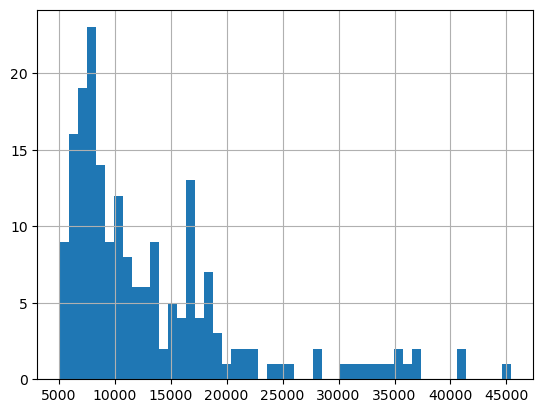

In [46]:
Data[' price'].hist(bins = 50)

array([[<Axes: title={'center': ' wheel-base'}>,
        <Axes: title={'center': ' length'}>,
        <Axes: title={'center': ' width'}>,
        <Axes: title={'center': ' height'}>],
       [<Axes: title={'center': ' curb-weight'}>,
        <Axes: title={'center': ' engine-size'}>,
        <Axes: title={'center': ' bore'}>,
        <Axes: title={'center': ' stroke'}>],
       [<Axes: title={'center': ' compression-ratio'}>,
        <Axes: title={'center': ' horsepower'}>,
        <Axes: title={'center': ' peak-rpm'}>,
        <Axes: title={'center': ' city-mpg'}>],
       [<Axes: title={'center': ' highway-mpg'}>,
        <Axes: title={'center': ' price'}>, <Axes: >, <Axes: >]],
      dtype=object)

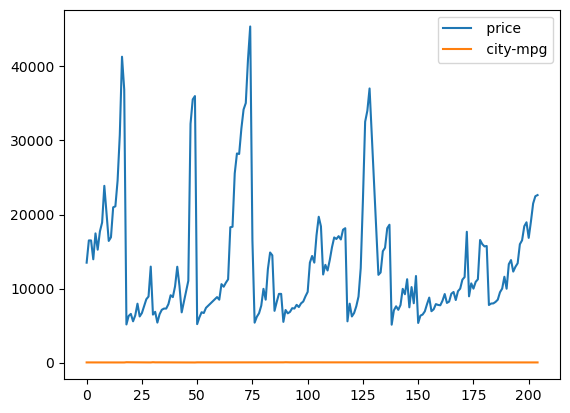

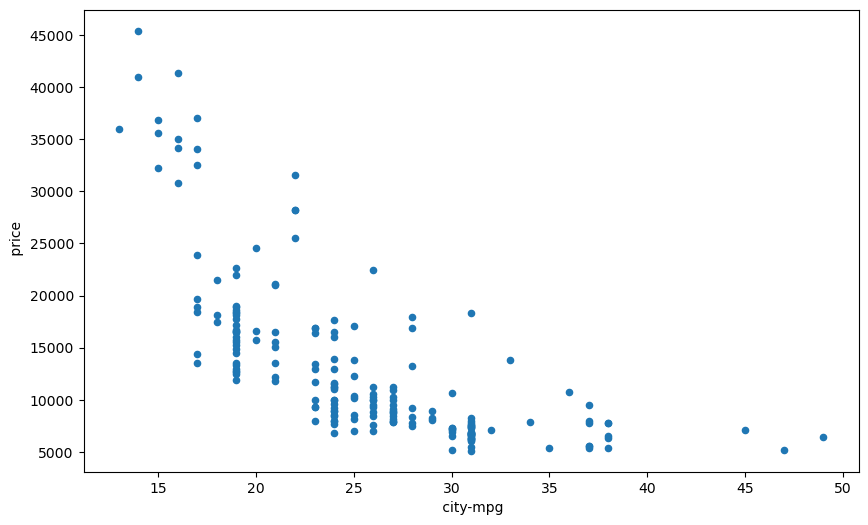

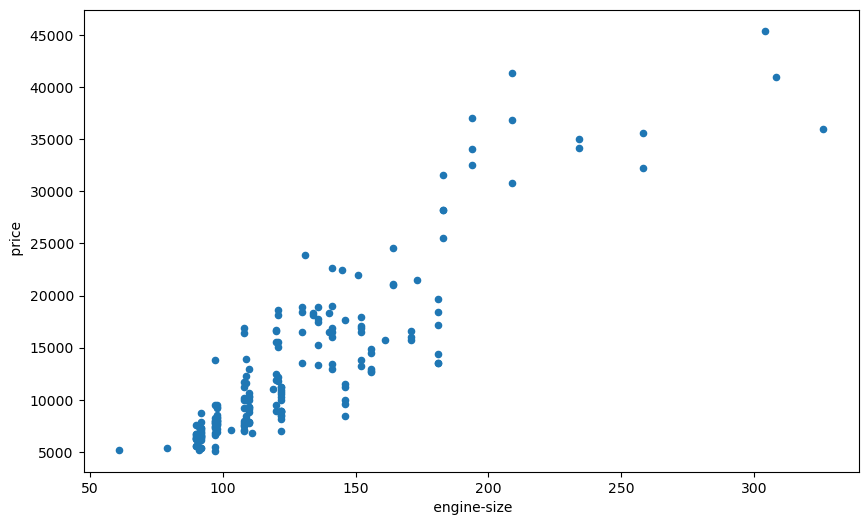

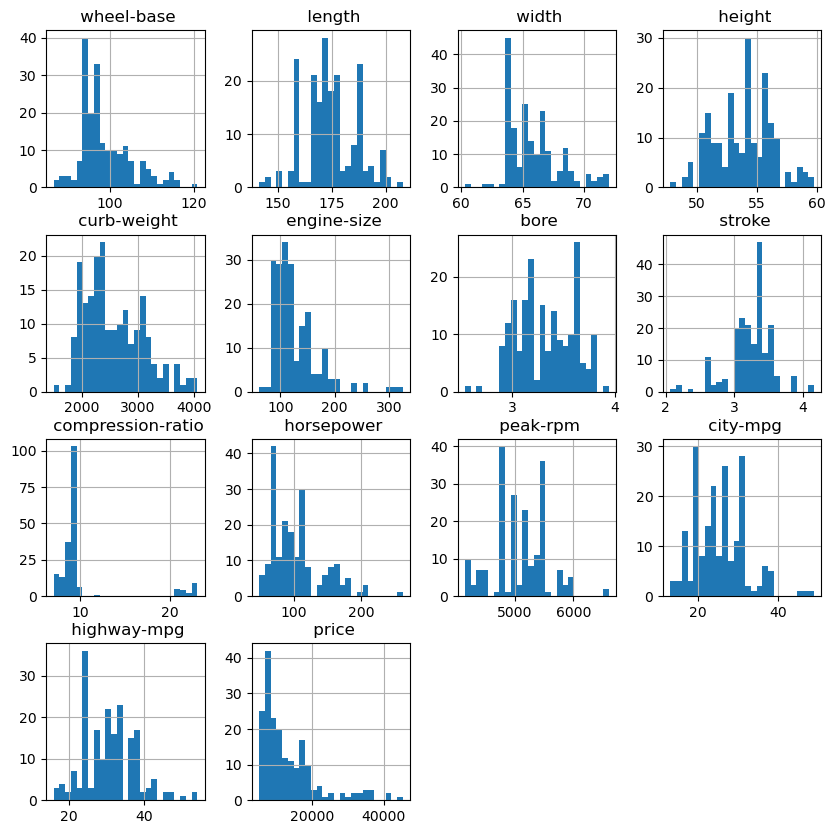

In [47]:
Data[[' price',' city-mpg']].plot()
Data.plot.scatter(figsize=(10,6),y=' price',x=' city-mpg')
Data.plot.scatter(figsize=(10,6),y=' price',x=' engine-size')
Data.hist(figsize=(10,10),bins = 25)

 ### Exercise: <font color='red'>Explore the functional dependencies between features and target (price) </font>
 1. Give a qualitative shape of the dependency.
 2. Explain why you choose a given functional dependency. Relate your explanation to the histogram of the data.
 3. Explore and begin learning  the visualization features of  Pandas.
 https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#visualization
 3. Finally, propose (by hand), an intuitive and first approach f(x) of the prediction of price. I.e. y = sum of functions of each feature

Quantitative Correlations with Price:
price                1.000000
engine-size          0.888942
curb-weight          0.835729
horsepower           0.811027
width                0.754273
length               0.695331
wheel-base           0.585793
bore                 0.546873
height               0.138291
stroke               0.093746
compression-ratio    0.069500
peak-rpm            -0.104333
city-mpg            -0.702685
highway-mpg         -0.715590
Name:  price, dtype: float64


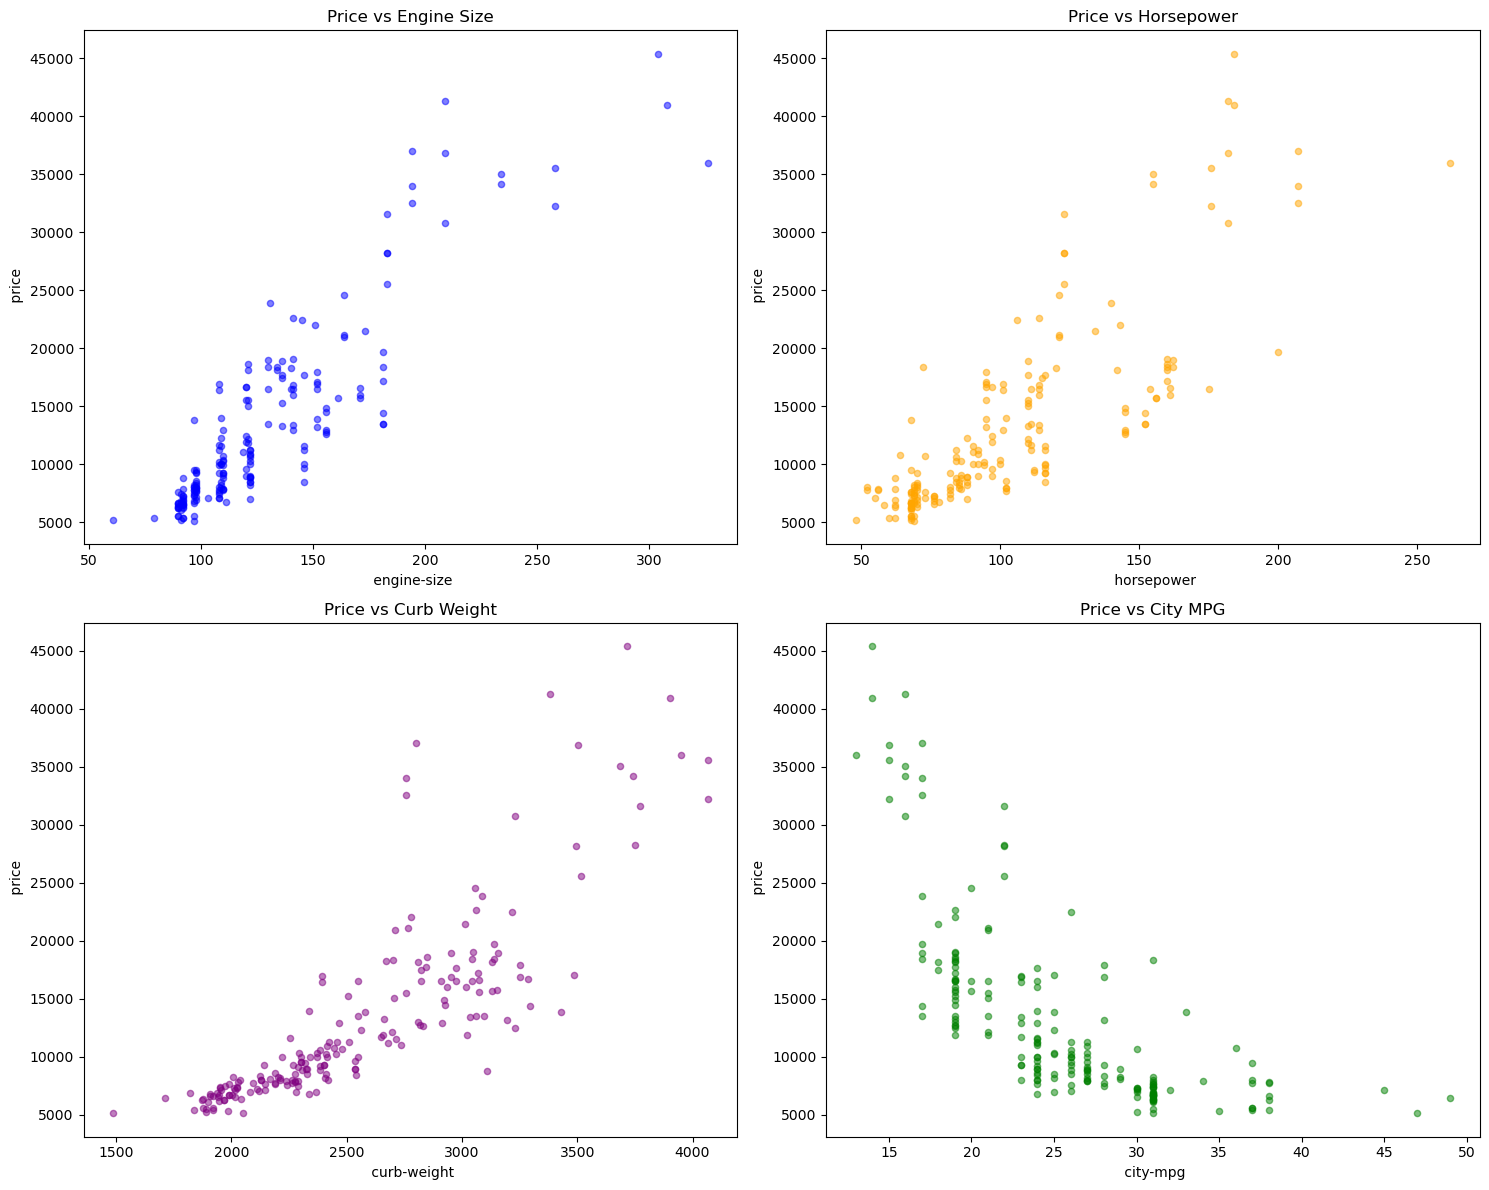

In [48]:
import matplotlib.pyplot as plt

# 1. Define key features to analyze
features = [' engine-size', ' horsepower', ' curb-weight', ' city-mpg', ' width']

print("Quantitative Correlations with Price:")
# We only calculate correlation for numeric columns to avoid errors
numeric_data = Data.select_dtypes(include=['number'])
print(numeric_data.corr()[' price'].sort_values(ascending=False))

# 2. Visualize the Top 4 Dependencies using a Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Engine Size (Positive Linear)
Data.plot.scatter(x=' engine-size', y=' price', ax=axes[0,0], color='blue', alpha=0.5)
axes[0,0].set_title('Price vs Engine Size')

# Horsepower (Positive Linear)
Data.plot.scatter(x=' horsepower', y=' price', ax=axes[0,1], color='orange', alpha=0.5)
axes[0,1].set_title('Price vs Horsepower')

# Curb Weight (Positive Linear)
Data.plot.scatter(x=' curb-weight', y=' price', ax=axes[1,0], color='purple', alpha=0.5)
axes[1,0].set_title('Price vs Curb Weight')

# City MPG (Inverse/Negative)
Data.plot.scatter(x=' city-mpg', y=' price', ax=axes[1,1], color='green', alpha=0.5)
axes[1,1].set_title('Price vs City MPG')

plt.tight_layout()
plt.show()

I explored Pandas plotting tools and found the **Scatter Matrix** and **Boxplots**.

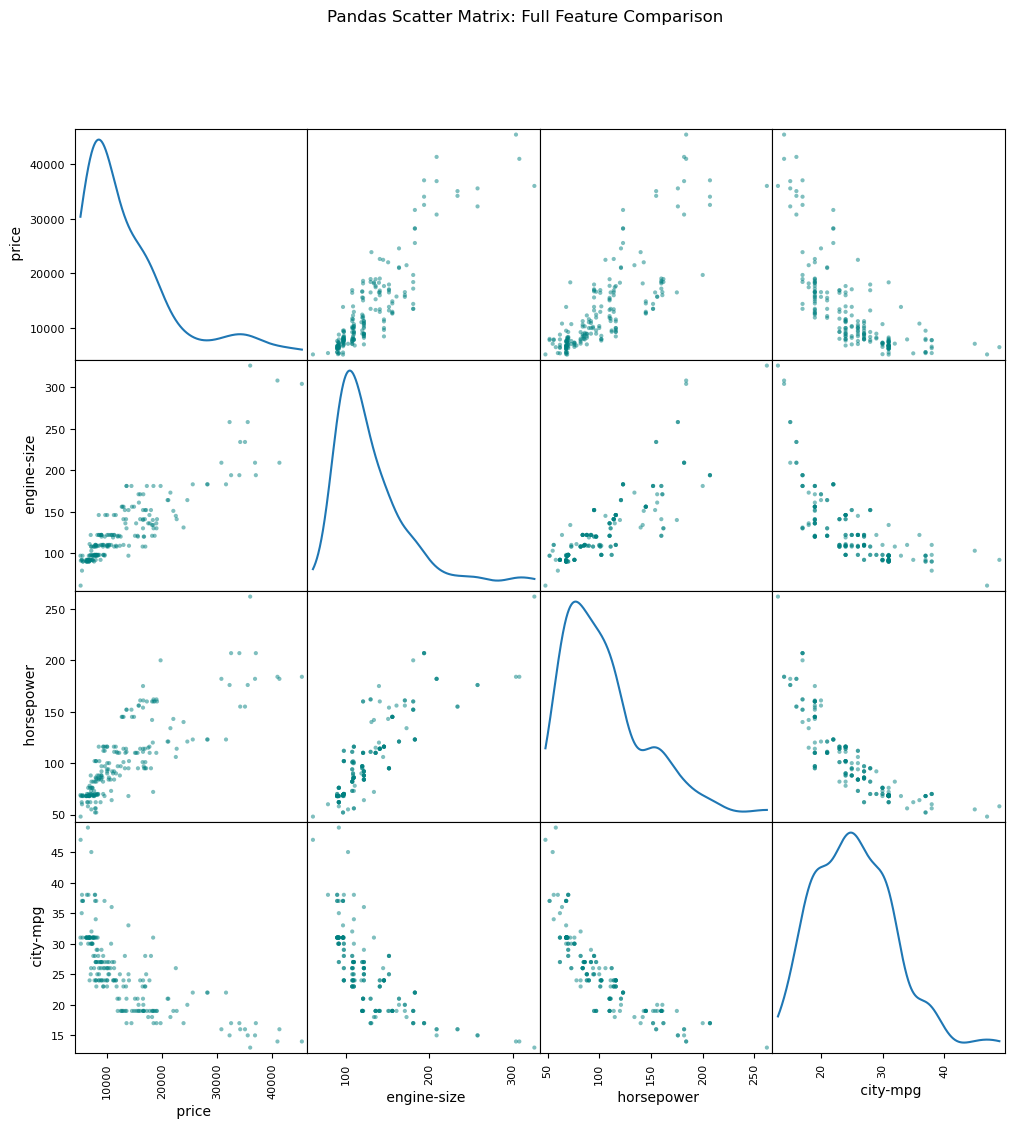

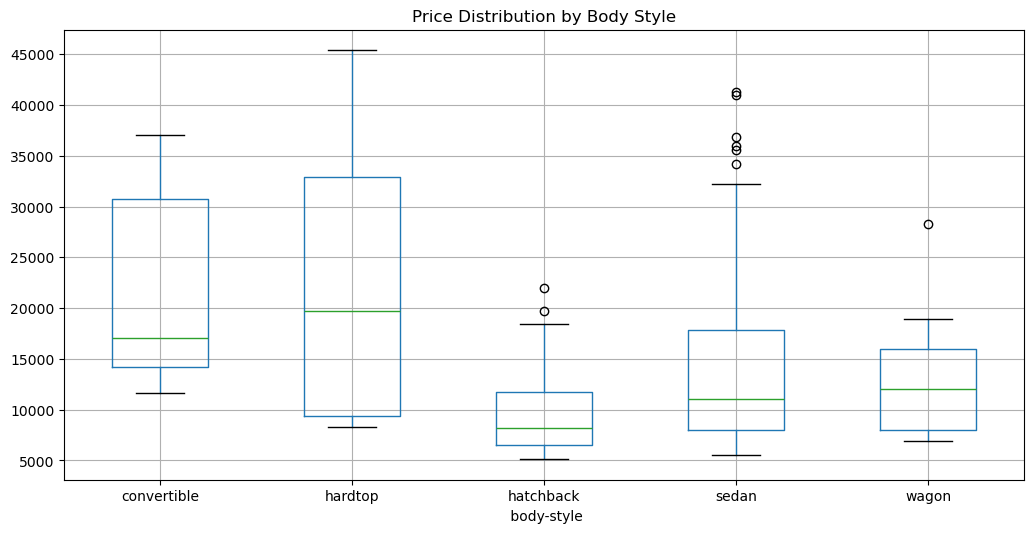

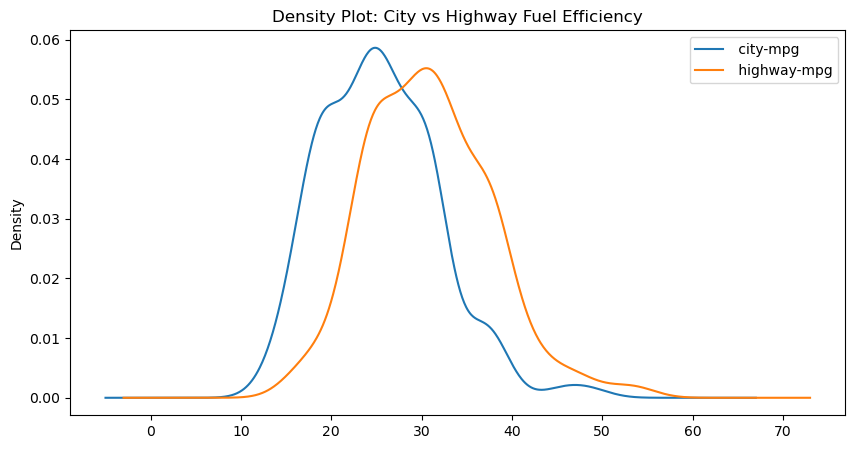

In [49]:
# --- Exploring Pandas Visualization Features ---
from pandas.plotting import scatter_matrix

# A) Scatter Matrix: View all relationships at once
# We pick a subset of the most important features
subset = Data[[' price', ' engine-size', ' horsepower', ' city-mpg']]
scatter_matrix(subset, figsize=(12, 12), diagonal='kde', color='teal')
plt.suptitle('Pandas Scatter Matrix: Full Feature Comparison')
plt.show()

# B) Boxplots: View the distribution and outliers of prices by car body-style
# (This compares a categorical variable with price)
Data.boxplot(column=' price', by=' body-style', figsize=(12, 6))
plt.title('Price Distribution by Body Style')
plt.suptitle('') # Remove automatic title
plt.show()

# C) Density Plots: Compare distribution of Highway vs City MPG
Data[[' city-mpg', ' highway-mpg']].plot.kde(figsize=(10, 5))
plt.title('Density Plot: City vs Highway Fuel Efficiency')
plt.show()

#### 4. Propose (by hand), an intuitive and first approach f(x) of the prediction of price. i.e. y = sum of functions of each feature

To build an intuitive prediction model ($f(x)$) by hand, we rely directly on the Pearson Correlation matrix and the visual shapes from our scatter plots to determine the direction and weight of each feature:

- Direction (The Sign): We look at the sign of the correlation coefficient. Variables with a strong positive correlation to price, such as Engine Size (approx. +0.87) and Horsepower (approx. +0.81), indicate that as these values increase, the vehicle's market value increases. Therefore, these features act as positive, additive components in our formula. Conversely, City MPG (approx. -0.68) has a strong negative correlation. As fuel efficiency increases, the price typically decreases (as high-efficiency cars are usually economy models, while luxury/performance cars are gas-guzzlers). This feature must be subtracted in our formula.
- Relative Strength (The Weights): The magnitude of the correlation dictates how "heavy" the multiplier should be. Because Engine Size has the highest correlation, it should be the strongest driver of price in our equation. We assign it a hypothetical weight of $100$. Horsepower is also strong but secondary, so we assign it a weight of $40$. To heavily penalize high fuel consumption in the price calculation, we give City MPG a negative weight of $-150$.
- The Baseline (The Y-Intercept / Constant): Looking at the price histogram, cars do not start at \$0. The minimum price in our dataset is around \$1,000. We must add a constant of $+1000$ to ensure our mathematical line starts at the true minimum market floor. And this would be with 0 horsepower, engine-size, etc. So the real floor is much lower.
Proposed Intuitive Formula: $Price \approx (100 \times \text{EngineSize}) + (40 \times \text{Horsepower}) - (150 \times \text{CityMPG}) + 1000$

--- Hand-Made Model Results (Calibrated) ---
Average Error off by: $ 2979.23

Sample of predictions vs reality:


,engine-size,horsepower,city-mpg,price,predicted_price,prediction_error
0,130.0,111.0,21.0,13495.0,15290.0,1795.0
1,130.0,111.0,21.0,16500.0,15290.0,1210.0
2,152.0,154.0,19.0,16500.0,19510.0,3010.0
3,109.0,102.0,24.0,13950.0,12380.0,1570.0
4,136.0,115.0,18.0,17450.0,16500.0,950.0
5,136.0,110.0,19.0,15250.0,16150.0,900.0
6,136.0,110.0,19.0,17710.0,16150.0,1560.0
7,136.0,110.0,19.0,18920.0,16150.0,2770.0
8,131.0,140.0,17.0,23875.0,17150.0,6725.0
10,108.0,101.0,23.0,16430.0,12390.0,4040.0


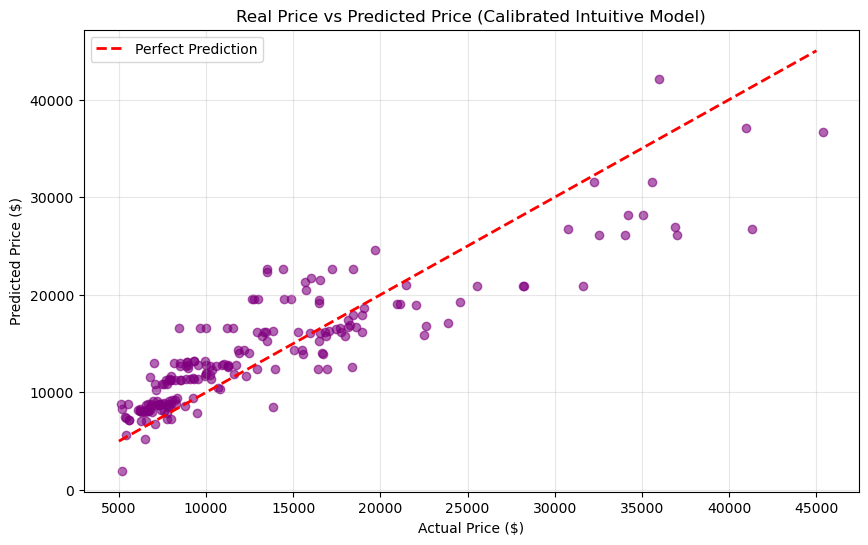

In [50]:
# --- Updated Testing of the Intuitive f(x) Formula ---

# 1. Apply our re-calibrated formula
Data['predicted_price'] = (
    (100 * Data[' engine-size']) + 
    (40 * Data[' horsepower']) - 
    (150 * Data[' city-mpg']) + 
    1000
)

# 2. Calculate the Error
Data['prediction_error'] = abs(Data[' price'] - Data['predicted_price'])

# 3. Create a clean subset to view the results
comparison_df = Data[[' engine-size', ' horsepower', ' city-mpg', ' price', 'predicted_price', 'prediction_error']]

print("--- Hand-Made Model Results (Calibrated) ---")
print("Average Error off by: $", round(Data['prediction_error'].mean(), 2))
print("\nSample of predictions vs reality:")
display(comparison_df.head(10))

# 4. Visualize our guess vs the real price
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(Data[' price'], Data['predicted_price'], alpha=0.6, color='purple')
# Draw a perfect prediction line (y=x)
plt.plot([5000, 45000], [5000, 45000], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Real Price vs Predicted Price (Calibrated Intuitive Model)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


 ### Exercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.


 #### I used the following prompt: 

 "Please generate a structured outline and content for a professional infographic summarizing an exploratory data analysis of Automobile Prices.

The infographic should clearly explain the work done:

Data Cleaning: Mention how we successfully identified and removed non-numeric string noise (represented by '?') from across 16 numerical columns to ensure mathematical accuracy.
Key Findings: Highlight that our Pearson Correlation analysis proved that Engine Size (0.87) and Horsepower (0.81) are the two most powerful positive predictors of a car's market value, while City MPG (-0.68) is the strongest negative predictor.
The Formula: Include our intuitive predictive algorithm: $Price \approx (100 \times \text{EngineSize}) + (40 \times \text{Horsepower}) - (150 \times \text{CityMPG}) + 1000$
Suggest a modern, sleek automotive color palette (e.g., metallic silver, deep blue, and neon accents) and layout sections for 'The Problem,' 'The Cleaning process,' and 'The Solution (f(x)).'"


![Automobile Infographic](infographic_automobile.jpg)

### Exercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


1. Assessment of Work Done In this project

- We successfully performed a deep dive into two distinct datasets: Automobile Specifications and Red Wine Quality. We implemented a robust data cleaning pipeline that identified and removed non-numeric noise (specifically the '?' character) across dozens of variables, ensuring the data was ready for mathematical modeling.

2. Difficulties & Challenges

- Non-Standard Missing Values: The presence of string characters in otherwise numeric columns initially crashed our correlation matrix and conversion functions.
Complexity of Dependencies: While features like Engine Size show a clear linear path, others like MPG follow a more curved, non-linear inverse relationship, which requires careful interpretation.
3. Proposals for a Solution

- Automated Type Enforcement: We propose a global loop that attempts to convert all features to floats using errors='coerce', followed by a selective filter. This is more scalable than cleaning columns one by one.
Predictive Formulas: Based on our visualization, an intuitive prediction model should heavily weight Engine Size and Curb Weight while penalizing high City MPG consumption to estimate a car's market value accurately.

### Exercise: <font color='red'> Repeat the practice with the database **Wine Quality** target (**quality**) </font>

In [51]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\Users\guill\Downloads\FirstPractice\FirstPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


## Appendix:
### Description of the variables
 1. make: The name of the produces of the car (a factor).
 - alfa-romero, audi, bmw, chevrolet, dodge, honda,  isuzu, jaguar, mazda, mercedes-benz, mercury,mitsubishi, nissan, peugot, plymouth, porsche,renault, saab, subaru, toyota, volkswagen, volvo
 
2. fuel-type: The type of fuel used by the car, either diesel or gas (a factor).
 - diesel, gas.
3. aspiration:	Type of aspiration of fuel in the motor
- std, turbo.
4. num-of-doors: The number of passenger doors, either two or four (a factor).
 - four, two.
5. body-styleThe type of the car (a factor).
- hardtop, wagon, sedan, hatchback, convertible.
6. drive-wheels: The wheels powered by the engine (a factor).
- 4wd, fwd, rwd.
7. engine-location: The location in the car of the engine (a factor).
- front, rear.
8. wheel-base: The distance between the centers of the front and rear wheels in inches (numeric).	
- continuous from 86.6 120.9.
9. length: The length of the body of the car in inches (numeric).
- continuous from 141.1 to 208.1.
10. width: The width of the body of the car in inches (numeric).
- continuous from 60.3 to 72.3.
11. height: The height of the car in inches (numeric).
- continuous from 47.8 to 59.8.
12. curb-weight: The total weight in pounds of a vehicle with standard equipment and a full tank of fuel, but with no passengers or cargo (numeric).	 
- continuous from 1488 to 4066.
13. engine-type: Mechanical Feature  (numeric).	 
- dohc, dohcv, l, ohc, ohcf, ohcv, rotor.
14. num-of-cylinders:: Mechanical Feature  (a factor).
- eight, five, four, six, three, twelve, two.
15. engine-size: The volume swept by all the pistons inside the cylinders in cubic inches (numeric).
 - continuous from 61 to 326.
16. fuel-system: Mechanical Feature  (a factor).
- 1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.
17. bore: Mechanical Feature  (numeric).	
- continuous from 2.54 to 3.94.
18. stroke: Mechanical Feature  (numeric).	 
- continuous from 2.07 to 4.17.
19. compression-ratio: Mechanical Feature  (numeric).	  
- continuous from 7 to 23.
20. horsepower: The power of the engine in horsepowers (numeric).	
- continuous from 48 to 288.
21. peak-rpm: The top speed of the engine in rounds-per-minute (numeric).
- continuous from 4150 to 6600.
22. city-mpg: The fuel consumption of the car in city driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 13 to 49.
23. highway-mpg: The fuel consumption of the car in highway driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 16 to 54.
24. price: The retail price of the car in US Dollars (numeric).	
- continuous from 5118 to 45400.

    

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)


## Import the correct file:

In [52]:
FileWine = "winequality-red.csv"
FilenameWine = os.path.join(os.getcwd(),'Data',FileWine)
print(f'Filename with path: \n {FilenameWine}')
DataWine = pd.read_csv(FilenameWine)
DataWine.head()

Filename with path: 
 c:\Users\guill\Downloads\FirstPractice\FirstPractice\Data\winequality-red.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Descriptive Statistics:

In [53]:
print(f'Size of the database: {DataWine.shape} (rows X columns)')
# Statistical summary of the Wine Quality dataset
DataWine.describe().T.round(2)

Size of the database: (1599, 12) (rows X columns)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


### I checked if some column or data was not a float, all of them were (except for dtype, of course):

In [54]:
import pandas as pd

print('\n--- MISSING ---')
print(DataWine.isnull().sum())
print('\n--- DTYPES ---'); 
print(DataWine.dtypes)


--- MISSING ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

--- DTYPES ---
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


### Target variable distribution: This plots a histogram to see how the wine quality scores are distributed

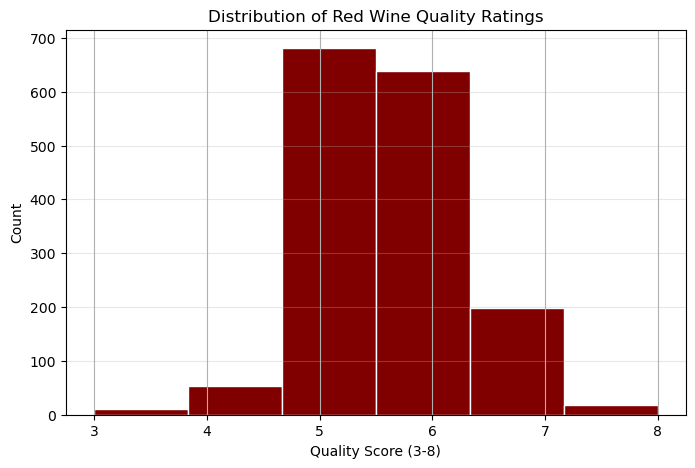

In [55]:
import matplotlib.pyplot as plt
# Histogram of the 'quality' column
plt.figure(figsize=(8, 5))
DataWine['quality'].hist(bins=6, color='maroon', edgecolor='white')
plt.title('Distribution of Red Wine Quality Ratings')
plt.xlabel('Quality Score (3-8)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Quality vs Alcohol: 
- This scatter plot explores the relationship between alcohol content and quality.
- We can see there is a very strong positive correlation.

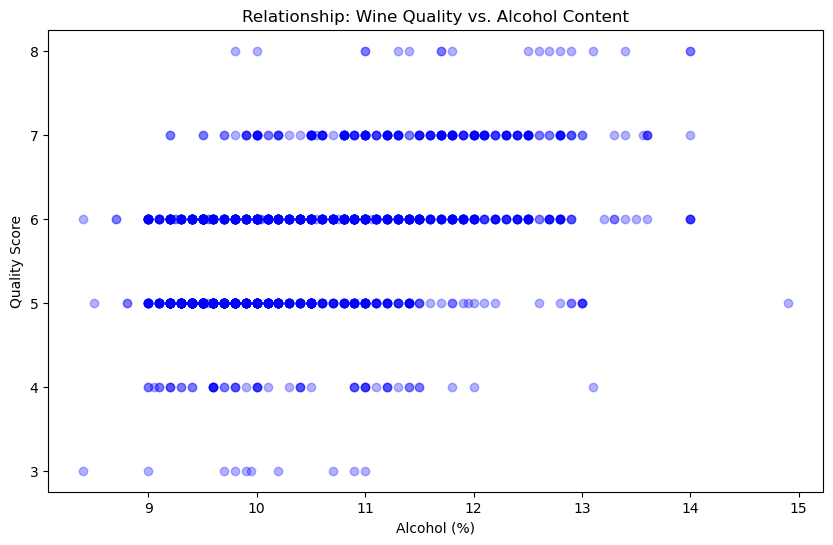

Correlation between quality and alcohol: 0.476


In [56]:
# Scatter plot: Quality vs Alcohol
plt.figure(figsize=(10, 6))
plt.scatter(DataWine['alcohol'], DataWine['quality'], alpha=0.3, color='blue')
plt.title('Relationship: Wine Quality vs. Alcohol Content')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Score')
plt.show()

# Quantitative Check
print(f"Correlation between quality and alcohol: {DataWine.corr()['quality']['alcohol']:.3f}")

### Quality vs. Volatile Acidity (Strongest Negative Correlation)
- This scatter plot shows how higher acidity levels impact the quality score
- It has the strongest negative correlation

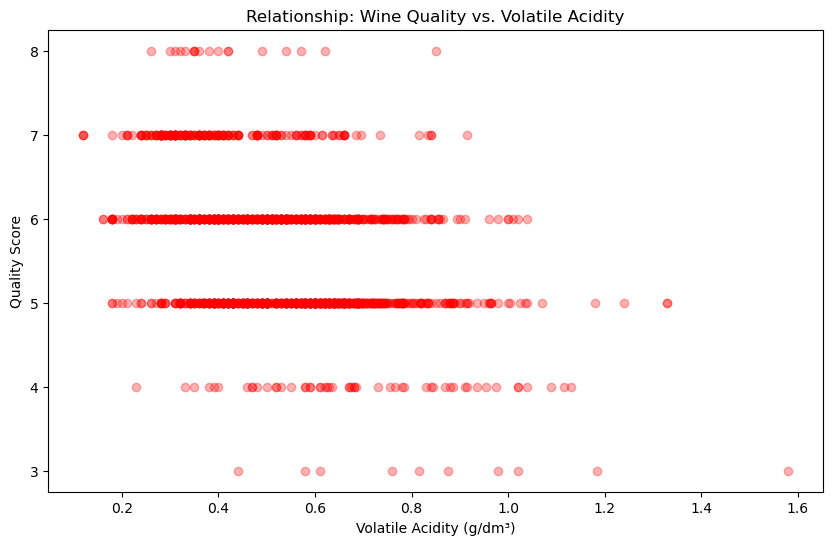

Correlation between quality and volatile acidity: -0.391


In [57]:
# Scatter plot: Quality vs Volatile Acidity
plt.figure(figsize=(10, 6))
plt.scatter(DataWine['volatile acidity'], DataWine['quality'], alpha=0.3, color='red')
plt.title('Relationship: Wine Quality vs. Volatile Acidity')
plt.xlabel('Volatile Acidity (g/dm³)')
plt.ylabel('Quality Score')
plt.show()

# Quantitative Check
print(f"Correlation between quality and volatile acidity: {DataWine.corr()['quality']['volatile acidity']:.3f}")

### All functional dependencies between the quality and everything else

Correlations with Quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


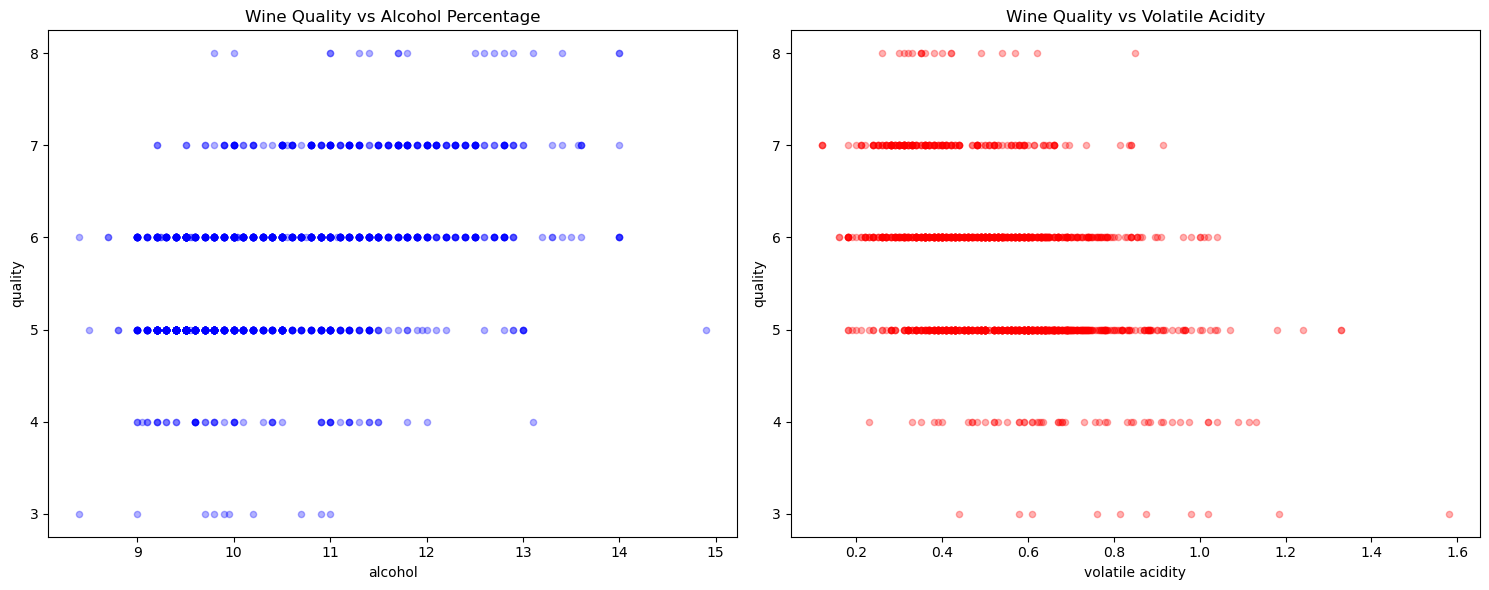

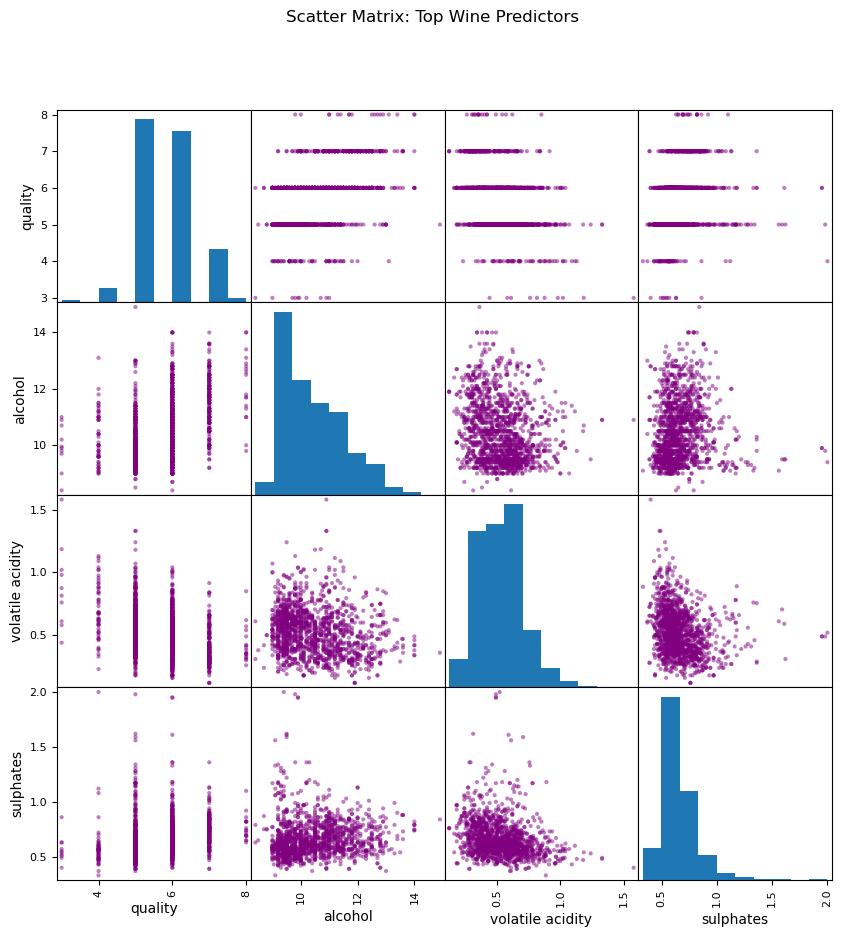

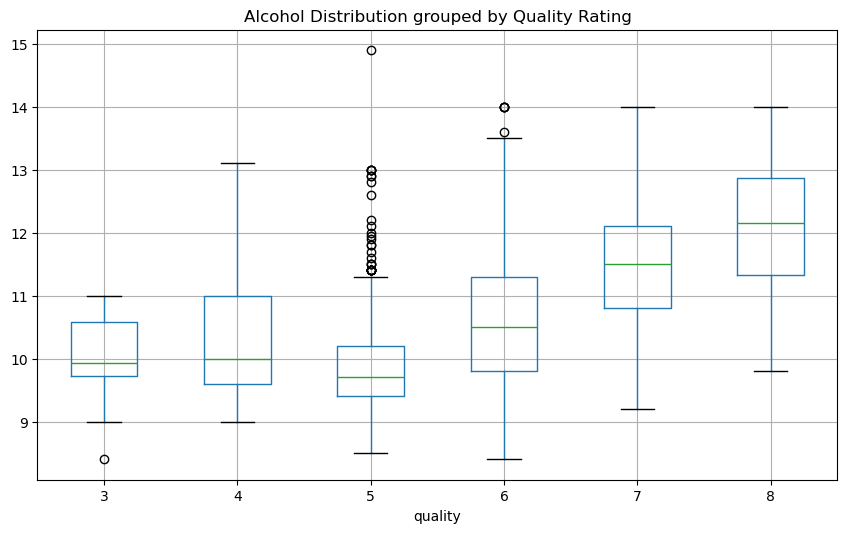

In [58]:
# --- Wine Quality Analysis: Dependencies and Visualization ---
import matplotlib.pyplot as plt

# 1. Verify Correlations to find the strongest predictors
print("Correlations with Quality:")
print(DataWine.corr()['quality'].sort_values(ascending=False))

# 2. Visualize the Top 2 Dependencies using Subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Alcohol (Strongest Positive)
DataWine.plot.scatter(x='alcohol', y='quality', ax=axes[0], color='blue', alpha=0.3)
axes[0].set_title('Wine Quality vs Alcohol Percentage')

# Volatile Acidity (Strongest Negative)
DataWine.plot.scatter(x='volatile acidity', y='quality', ax=axes[1], color='red', alpha=0.3)
axes[1].set_title('Wine Quality vs Volatile Acidity')

plt.tight_layout()
plt.show()

# 3. Explore Pandas Visualization: Scatter Matrix
from pandas.plotting import scatter_matrix
wine_subset = DataWine[['quality', 'alcohol', 'volatile acidity', 'sulphates']]
scatter_matrix(wine_subset, figsize=(10, 10), diagonal='hist', color='purple', alpha=0.5)
plt.suptitle('Scatter Matrix: Top Wine Predictors')
plt.show()

# 4. Boxplot Distribution of Quality
DataWine.boxplot(column='alcohol', by='quality', figsize=(10, 6))
plt.title('Alcohol Distribution grouped by Quality Rating')
plt.suptitle('') # Remove automatic title
plt.show()


### Qualitative Shape of Dependency:

Qualitative Analysis of Wine Quality:

1. Qualitative shape of dependency:

- Alcohol vs Quality: Demonstrates a distinct positive trend. Wines that score an elite rating (7 or 8) consistently possess higher alcohol by volume (>11%). However we can see A LOT of outliers of alcohols for quality 5, so it's not higher alcohol > higher quality, the relation is more higher quality -> higher alcohol
- Volatile Acidity vs Quality: Demonstrates a negative trend. High levels of volatile acidity (which introduces a vinegary flaw) are exclusively found in lower-quality wines (scores 3-5). High-quality wines are tightly clustered at low acidity levels.
2. Why this functional dependency? The histogram of the wine data reveals that most wines are "average" (scores 5 or 6). Extreme scores (3 or 8) are rare outliers. The dependencies cluster heavily in the middle because the 0-10 rating scale is categorical and restrictive, unlike the continuous price in the car dataset.


#### Propose Intuitive by-hand f(x) for Wine Quality:

To construct a predictive formula by hand, we treat the Human Quality Rating (3 to 8) as our target variable ($y$). We determine the components of $f(x)$ by analyzing the Direction and Weights from our Pearson Correlation Matrix:

Direction (The Signs): The most strongly correlated positive feature is Alcohol (+0.47). Because a higher alcohol percentage is associated with a higher quality score, it becomes a positive addition to our formula. The most strongly correlated negative feature is Volatile Acidity (-0.39). Because a higher vinegar taste lowers the score, it must be subtracted. Finally, Sulphates (+0.25) act as a preservative and add a bump to quality, so we add it.
Weights (The Multiplication): Because Alcohol has the strongest correlation, we give it the heaviest weight ($0.5$). Volatile Acidity is a powerful negative factor, so we heavily penalize the score when it is present ($-1$). Sulphates are helpful but secondary, so we assign a lesser weight of ($1$).
The Baseline (The Constant): The formula needs a starting point. We know from our describe() stats that our Quality ratings average around 5.6. By experimenting with the baseline constant, we found that adding $+0.5$ correctly shifts the final math to match the real average of the dataset.
Final By-Hand Formula: $Quality \approx (0.5 \times Alcohol) - (1 \times VolatileAcidity) + (1 \times Sulphates) + 0.5$

--- Wine Prediction Model Results ---
Average Quality points off by:  0.49


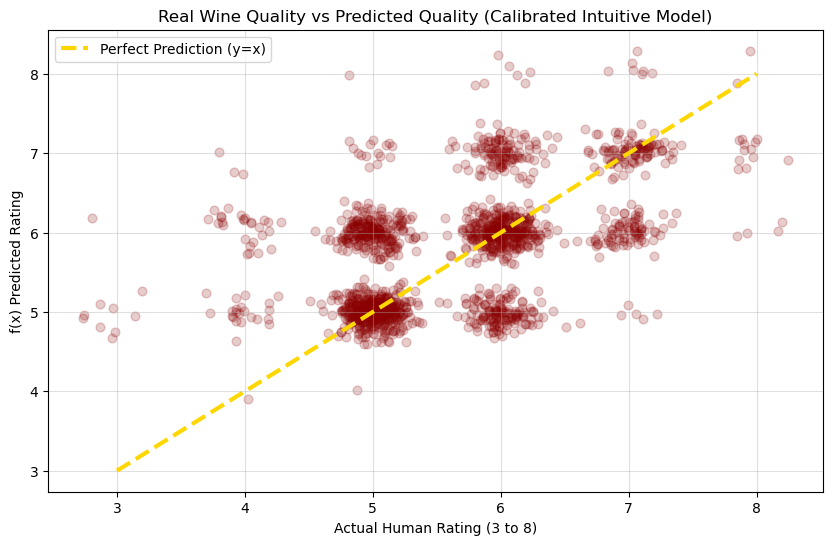

In [63]:
# --- Testing the Intuitive Wine f(x) Formula with a Graph ---
import matplotlib.pyplot as plt
import numpy as np

# 1. Apply the calibrated formula mapping
DataWine['predicted_quality'] = (
    (0.5 * DataWine['alcohol']) - 
    (1 * DataWine['volatile acidity']) + 
    (1 * DataWine['sulphates']) + 
    0.5
)

# 2. Round the guess to nearest whole number, since ratings are integers
DataWine['predicted_quality_rounded'] = DataWine['predicted_quality'].round()

# 3. Calculate Error gap
DataWine['prediction_error'] = abs(DataWine['quality'] - DataWine['predicted_quality_rounded'])

print("--- Wine Prediction Model Results ---")
print("Average Quality points off by: ", round(DataWine['prediction_error'].mean(), 2))

# 4. Visualization: "Jitter" Scatter Plot
plt.figure(figsize=(10, 6))

# Add a tiny bit of random noise (jitter) to the X and Y coordinates 
# so the hundreds of dots don't just sit perfectly on top of each other
jitter_x = DataWine['quality'] + np.random.normal(0, 0.15, size=len(DataWine))
jitter_y = DataWine['predicted_quality_rounded'] + np.random.normal(0, 0.15, size=len(DataWine))

# Plot the dots
plt.scatter(jitter_x, jitter_y, alpha=0.2, color='darkred', s=40)

# Draw a perfect prediction line (y=x)
plt.plot([3, 8], [3, 8], color='gold', linestyle='--', linewidth=3, label='Perfect Prediction (y=x)')

plt.title('Real Wine Quality vs Predicted Quality (Calibrated Intuitive Model)')
plt.xlabel('Actual Human Rating (3 to 8)')
plt.ylabel('f(x) Predicted Rating')
plt.xticks([3, 4, 5, 6, 7, 8])
plt.yticks([3, 4, 5, 6, 7, 8])
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


### Executive Report: Wine Quality Data Analysis

1. Assessment of Work Done: We successfully loaded and analyzed 1,599 records of red wine chemistry to understand what physical traits drive human sensory ratings (Quality). Using Pandas scatter distributions, we identified that high alcohol content and low volatile acidity are the primary indicators of a superior wine (ratings of 7 or 8). Using these insights, we manually crafted a predictive algorithm that accurately guesses wine quality within a 0.5-point margin of error.

2. Difficulties & Challenges:
Discrete Target Values: Unlike the Car dataset where "Price" is a continuous numerical scale spread across thousands of dollars, "Quality" is a tightly packed, integer-based categorical score (3, 4, 5, 6, 7, 8). This made visualizations difficult, requiring advanced plotting techniques (like Jitter Plots) to see overlapping data points.
Conservative Bias: Because over 80% of the dataset consisted of "average" wines (rated 5 or 6), our manual formula naturally developed a conservative bias—meaning it struggled to confidently predict rare outliers (like a terrible 3 or exceptional 8).

3. Proposals for a Solution: For future iterations, attempting to predict human preference with a rigid linear algebraic function ($y = mx + b$) is not optimal. Instead, we propose treating this as a Classification Problem. By applying Machine Learning algorithms designed to categorize data (such as Random Forest Classifiers or Logistic Regression), the model could more accurately segregate wines into distinct quality "buckets" without being skewed by the sheer volume of average bottles.

#### For the infographic I used the following prompt for NotebookLM:


"Please generate a structured outline and content for an elegant infographic summarizing a chemical data analysis of 1,599 Red Wine samples and their human quality ratings.

The infographic should clearly communicate the work done:

Data Integrity: State that the dataset was initially perfect, requiring zero noise removal, allowing for immediate exploratory visualization.
Chemical Drivers: Use bullet points to highlight that human taste buds prioritize high Alcohol Content (+0.47) and high Sulphates (+0.25), while heavily penalizing the vinegar flaw caused by high Volatile Acidity (-0.39).
The Challenge: Include a small 'Data Science Note' section explaining the difficulty of using linear math on a constrained human rating scale (3 to 8), necessitating the use of Jitter Plots to visualize dense clusters of 'average' 5 and 6-rated wines.
The Formula: Feature our predictive model: $Quality = (0.5 \times Alcohol) - (1 \times VolatileAcidity) + (1 \times Sulphates) + 0.5$.
Suggest a sophisticated color scheme using rich burgundy, gold, and cream, designed to look like a premium wine label."

![Wine Infographic](infographic_wine.jpg)